<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5/day5/exercise/mini_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p data/cats_dogs
# Téléchargement depuis une source alternative fiable
!wget -O cats_dogs.zip https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
!unzip -q cats_dogs.zip -d data/

# Organisation des dossiers pour correspondre au script de chargement
!mkdir -p data/cats_dogs/train/cat data/cats_dogs/train/dog
# On déplace une partie des images pour simuler la structure attendue
!mv data/PetImages/Cat/*.jpg data/cats_dogs/train/cat/ 2>/dev/null || true
!mv data/PetImages/Dog/*.jpg data/cats_dogs/train/dog/ 2>/dev/null || true

# Nettoyage
!rm -rf data/PetImages cats_dogs.zip
print("Données téléchargées et organisées.")

--2026-06-20 09:16:45--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.62.176.164, 2600:1406:5400:2ae::317f, 2600:1406:5400:2ac::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.62.176.164|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘cats_dogs.zip’

cats_dogs.zip       100%[===================>] 786.67M   154MB/s    in 5.2s    

2026-06-20 09:16:50 (151 MB/s) - ‘cats_dogs.zip’ saved [824887076/824887076]

Données téléchargées et organisées.


Found 12500 images in data/cats_dogs/train/cat
Found 12500 images in data/cats_dogs/train/dog


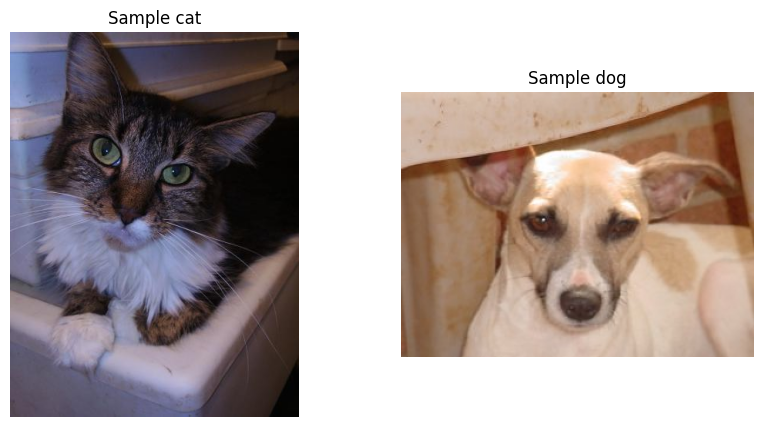

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Check directory counts
for cls in ['cat', 'dog']:
    path = f'data/cats_dogs/train/{cls}'
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"Found {count} images in {path}")
    else:
        print(f"Directory {path} does not exist.")

# Display a few samples
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, cls in enumerate(['cat', 'dog']):
    path = f'data/cats_dogs/train/{cls}'
    img_name = os.listdir(path)[0]
    img = mpimg.imread(os.path.join(path, img_name))
    axes[i].imshow(img)
    axes[i].set_title(f"Sample {cls}")
    axes[i].axis('off')
plt.show()

In [3]:
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

np.random.seed(42); tf.random.set_seed(42)

# Configuration des chemins
DATA_ROOT = Path("data/cats_dogs")
train_dir = DATA_ROOT / "train"
# On crée un dossier test vide s'il n'existe pas pour éviter les erreurs
(DATA_ROOT / "test").mkdir(parents=True, exist_ok=True)
test_dir = DATA_ROOT / "test"

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        return pd.DataFrame(columns=(["filepath", "label"] if labeled else ["filepath"]))

    rows = []
    for f in files:
        if labeled:
            parent = Path(f).parent.name.lower()
            label = "cat" if "cat" in parent else "dog"
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

# Construction des DataFrames
df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full = build_df_from_folder(test_dir, labeled=False)

# Train validation split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Générateurs
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode="binary",
    batch_size=batch_size, shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode="binary",
    batch_size=batch_size, shuffle=False, validate_filenames=False
)

print({"train_samples": train_flow.samples, "val_samples": val_flow.samples, "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
{'train_samples': 20000, 'val_samples': 5000, 'class_indices': {'cat': 0, 'dog': 1}}


In [4]:
from tensorflow.keras import layers, models

# Définition du modèle CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,308,673 (100.36 MB)

 Trainable params: 26,308,673 (100.36 MB)

 Non-trainable params: 0 (0.00 B)

Nettoyage des images corrompues...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Nettoyage terminé. 0 images corrompues supprimées.
Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6586 - loss: 0.6171

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 319ms/step - accuracy: 0.6704 - loss: 0.6046 - val_accuracy: 0.7290 - val_loss: 0.5253
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.6958 - loss: 0.5766 - val_accuracy: 0.7608 - val_loss: 0.5056
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 308ms/step - accuracy: 0.7205 - loss: 0.5442 - val_accuracy: 0.7600 - val_loss: 0.4919
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 305ms/step - accuracy: 0.7320 - loss: 0.5314 - val_accuracy: 0.7556 - val_loss: 0.4876
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 310ms/step - accuracy: 0.7459 - loss: 0.5152 - val_accuracy: 0.7990 - val_loss: 0.4323
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.7552 - loss: 0.5009 - val_accuracy: 0.7948 - val_loss: 0.4530
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 305ms/step - accuracy: 0.7616 - loss: 0.4930 - val_accuracy: 0.8070 - val_loss: 0.4146
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.7737 - loss: 0.47

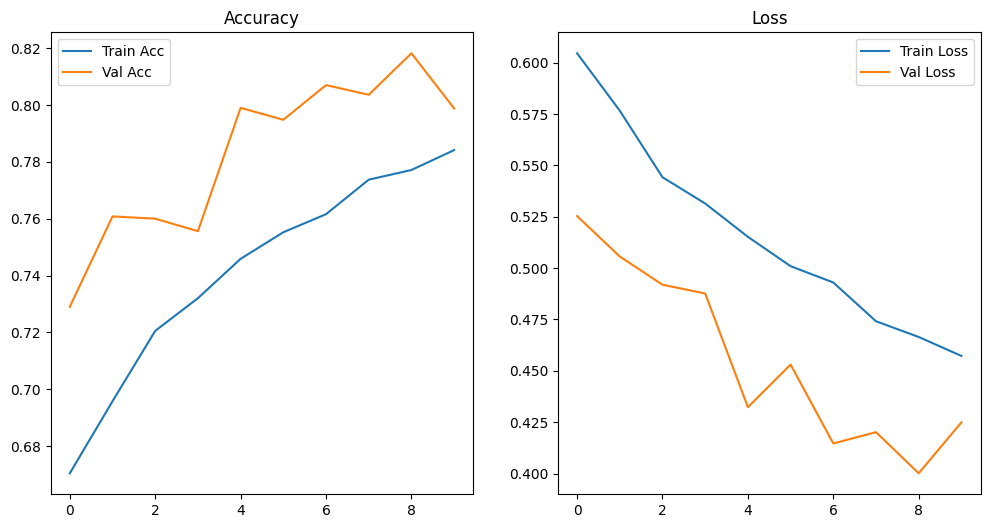

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
import os
from PIL import Image

# 1. Nettoyage des images corrompues
print("Nettoyage des images corrompues...")
num_skipped = 0
for folder in ['cat', 'dog']:
    path = os.path.join('data/cats_dogs/train', folder)
    for filename in os.listdir(path):
        filepath = os.path.join(path, filename)
        try:
            img = Image.open(filepath)
            img.verify()
        except (IOError, SyntaxError, Image.UnidentifiedImageError):
            os.remove(filepath)
            num_skipped += 1

print(f"Nettoyage terminé. {num_skipped} images corrompues supprimées.")

# 2. Mise à jour des DataFrames et des générateurs
# On reconstruit df_train_full pour exclure les fichiers supprimés
df_train_full = build_df_from_folder(train_dir, labeled=True)
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full['label'], random_state=seed
)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col='filepath', y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode='binary',
    batch_size=batch_size, shuffle=True, seed=seed, validate_filenames=True
)

val_flow = val_gen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode='binary',
    batch_size=batch_size, shuffle=False, validate_filenames=True
)

# 3. Entraînement
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_flow,
    epochs=10,
    validation_data=val_flow,
    callbacks=[early_stop]
)

# 4. Visualisation
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

132/157 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step
              precision    recall  f1-score   support

         cat       0.83      0.80      0.81      2500
         dog       0.80      0.84      0.82      2500

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000



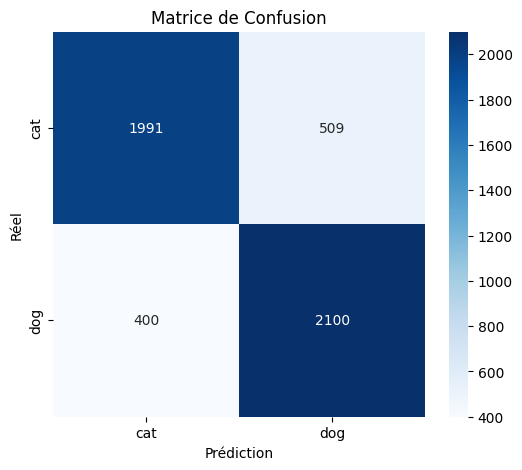

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 6. Évaluation sur les données de validation
val_flow.reset()
y_pred_probs = model.predict(val_flow)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = val_flow.classes

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=['cat', 'dog']))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['cat', 'dog'], yticklabels=['cat', 'dog'])
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

In [11]:
# 10. Sauvegarde du modèle
model.save('cats_dogs_cnn_model.keras')
print("Modèle sauvegardé sous 'cats_dogs_cnn_model.keras'")

Modèle sauvegardé sous 'cats_dogs_cnn_model.keras'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step


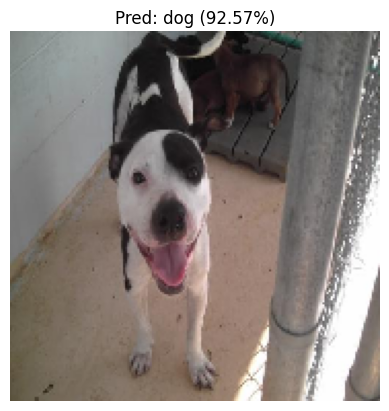

In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = 'dog' if prediction[0][0] > 0.5 else 'cat'
    confidence = prediction[0][0] if label == 'dog' else 1 - prediction[0][0]

    plt.imshow(img)
    plt.title(f"Pred: {label} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

# Exemple sur une image du set de validation
sample_path = df_val.iloc[0]['filepath']
predict_image(sample_path)